In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "./CELLDNA_3_Files/"
X1 = pd.read_csv(DATA_PATH + "CellDNA_data1.csv", header=None).values.astype(np.float32)
X2 = pd.read_csv(DATA_PATH + "CellDNA_data2.csv", header=None).values.astype(np.float32)
Y  = pd.read_csv(DATA_PATH + "CellDNA_targets.csv", header=None).values.squeeze()

print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)
print("Y shape :", Y.shape)

X1 shape: (1217, 6)
X2 shape: (1217, 7)
Y shape : (1217,)


In [3]:
scaler1 = StandardScaler()
scaler2 = StandardScaler()

X1_std = scaler1.fit_transform(X1).astype(np.float32)
X2_std = scaler2.fit_transform(X2).astype(np.float32)

In [4]:
Y_bin = (Y != 0).astype(np.float32)

X1_tensor = torch.tensor(X1_std, dtype=torch.float32)
X2_tensor = torch.tensor(X2_std, dtype=torch.float32)
Y_tensor  = torch.tensor(Y_bin.reshape(-1, 1), dtype=torch.float32)

dataset = TensorDataset(X1_tensor, X2_tensor, Y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
class TwoInputNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Linear(6, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.branch2 = nn.Sequential(
            nn.Linear(7, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x1, x2):
        z1 = self.branch1(x1)
        z2 = self.branch2(x2)
        z = torch.cat((z1, z2), dim=1)
        out = self.classifier(z)
        return out

In [6]:
def BCE(logits, targets, eps=1e-8):
    probs = torch.sigmoid(logits)
    probs = torch.clamp(probs, eps, 1 - eps)
    loss = -(targets * torch.log(probs) + (1 - targets) * torch.log(1 - probs))
    return loss.mean()

def train(model, loader, epochs=200, lr=0.001):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_samples = 0
        for xb1, xb2, yb in loader:
            xb1 = xb1.to(device)
            xb2 = xb2.to(device)
            yb  = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb1, xb2)
            loss = BCE(logits, yb)
            loss.backward()
            optimizer.step()
            batch_size = yb.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        epoch_loss = total_loss / total_samples
        loss_history.append(epoch_loss)
        
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")
    return loss_history

def evaluate(model, loader, threshold=0.5):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb1, xb2, yb in loader:
            xb1 = xb1.to(device)
            xb2 = xb2.to(device)

            logits = model(xb1, xb2)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(yb.cpu().numpy().flatten())

    all_preds = np.array(all_preds).astype(int)
    all_targets = np.array(all_targets).astype(int)

    cm = confusion_matrix(all_targets, all_preds)
    acc = (all_preds == all_targets).mean()

    return cm, acc, all_preds

In [7]:
def main():
    model = TwoInputNN().to(device)
    loss_history = train(model, loader, epochs=2000, lr=0.001)
    cm_a, acc_a, preds_a = evaluate(model, loader)
    print("Accuracy:", acc_a)
    return cm_a, loss_history

if __name__ == "__main__":
    cm_a, loss_history = main()


Epoch 1/2000, Loss: 0.773497
Epoch 100/2000, Loss: 0.469014
Epoch 200/2000, Loss: 0.422829
Epoch 300/2000, Loss: 0.379474
Epoch 400/2000, Loss: 0.315243
Epoch 500/2000, Loss: 0.269975
Epoch 600/2000, Loss: 0.235665
Epoch 700/2000, Loss: 0.200141
Epoch 800/2000, Loss: 0.180867
Epoch 900/2000, Loss: 0.171137
Epoch 1000/2000, Loss: 0.165204
Epoch 1100/2000, Loss: 0.161386
Epoch 1200/2000, Loss: 0.158270
Epoch 1300/2000, Loss: 0.155822
Epoch 1400/2000, Loss: 0.153872
Epoch 1500/2000, Loss: 0.152282
Epoch 1600/2000, Loss: 0.150833
Epoch 1700/2000, Loss: 0.149619
Epoch 1800/2000, Loss: 0.148559
Epoch 1900/2000, Loss: 0.147664
Epoch 2000/2000, Loss: 0.146707
Accuracy: 0.9301561216105176


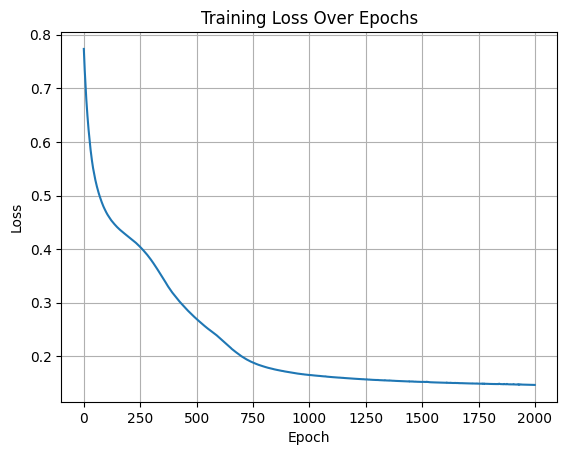

In [8]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()
plt.show()

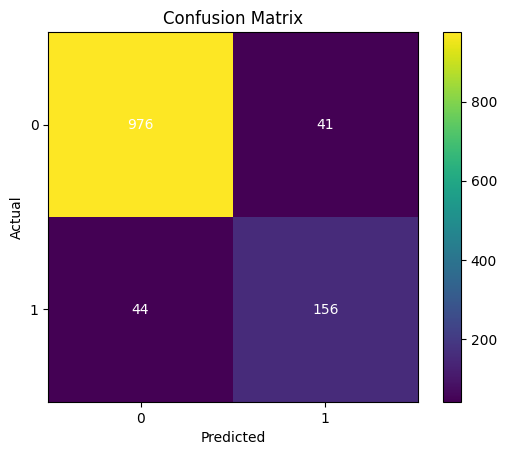

In [9]:


plt.figure()
plt.imshow(cm_a)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ['0', '1']
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# Add numbers inside the boxes
for i in range(cm_a.shape[0]):
    for j in range(cm_a.shape[1]):
         plt.text(j, i, cm_a[i, j],
                    ha="center", va="center", color="white")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
